# 0.5 - GL Model Investigation

Another model basing on reconciliation using the GL as opposed to claim status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

support_file = Path("SupportData.xlsx")
gl_account_file = Path("GLAccountData.xlsx")
gl_entry_file = Path("GLEntryData.xlsx")

clean_data_dir = Path("outputs") / "cleaned_data"
support_cleaned_file = clean_data_dir / "support_cleaned.csv"
gl_accounts_cleaned_file = clean_data_dir / "gl_accounts_cleaned.csv"
gl_entries_cleaned_file = clean_data_dir / "gl_entries_cleaned.csv"

def read_cleaned_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset not found: {path}. Run 0.2 - Data Cleaning first.")
    df = pd.read_csv(path, low_memory=False)
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

random_state = 42

def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip().str.replace(".", "_", regex=False).str.replace(" ", "_", regex=False)
    return df

def normalise_key(series):
    return series.astype("string").str.strip().str.upper().str.replace(r"\.0$", "", regex=True)

def normalise_gl_description(series):
    return (series.astype("string").str.upper()
        .str.replace(r"\bCLAIMBACKS?\b", "", regex=True)
        .str.replace(r"\b[A-Z]\d+[A-Z]*\b", "", regex=True)
        .str.replace(r"\bLIMITED\b|\bLTD\b", "", regex=True)
        .str.replace(r"\s+", " ", regex=True).str.strip())

def build_model_base_from_support():
    df = clean_columns(read_cleaned_dataset(support_cleaned_file))
    df["claim_line_id"] = np.arange(1, len(df) + 1)
    df["claim_date"] = pd.to_datetime(df.get("Date"), errors="coerce", dayfirst=True)
    df["customer_date"] = df["claim_date"]
    df["customer_year"] = df["claim_date"].dt.year
    df["customer_month"] = df["claim_date"].dt.month
    qty = pd.to_numeric(df.get("SalesDeliveryNoteLine_Quantity"), errors="coerce").fillna(pd.to_numeric(df.get("SalesInvoiceLine_Quantity"), errors="coerce")).fillna(0)
    unit = pd.to_numeric(df.get("UnitClaimAmount"), errors="coerce").fillna(0)
    total = pd.to_numeric(df.get("TotalClaimAmount"), errors="coerce")
    df["credit_due_value"] = total.fillna(unit * qty)
    credit_note = df.get("SalesCreditNote_Number", pd.Series("", index=df.index)).astype("string").str.strip().ne("").fillna(False)
    df["credit_received_value"] = np.where(credit_note.to_numpy(dtype=bool), df["credit_due_value"].clip(lower=0), 0)
    df["outstanding_credit_value"] = df["credit_due_value"] - df["credit_received_value"]
    df["recovered_credit_rate"] = df["credit_received_value"].div(df["credit_due_value"].replace(0, np.nan)).fillna(0)
    df["supplier_reference_value"] = df["credit_due_value"]
    df["supplier_reference_match_status"] = "Derived from SupportData.xlsx"
    has_received_credit = df["credit_received_value"].gt(0).fillna(False)
    has_outstanding_credit = df["outstanding_credit_value"].gt(0).fillna(False)
    df["credit_recovery_status"] = np.select(
        [has_received_credit.to_numpy(dtype=bool), has_outstanding_credit.to_numpy(dtype=bool)],
        ["Credit note present", "Outstanding"],
        default="No claim value",
    )
    df["days_outstanding"] = (pd.Timestamp.today().normalize() - df["claim_date"]).dt.days
    df["ageing_band"] = pd.cut(df["days_outstanding"], [-1,30,60,90,180,365,np.inf], labels=["0-30","31-60","61-90","91-180","181-365","365+"])
    df["requires_review"] = has_outstanding_credit
    df["review_reason"] = np.where(has_outstanding_credit.to_numpy(dtype=bool), "Outstanding credit value", "")
    return df

def load_gl_context():
    accounts = clean_columns(read_cleaned_dataset(gl_accounts_cleaned_file))
    entries = clean_columns(read_cleaned_dataset(gl_entries_cleaned_file))
    if not accounts.empty:
        accounts["gl_account_code"] = normalise_key(accounts.get("Code", pd.Series(pd.NA,index=accounts.index)))
        accounts["gl_account_description"] = accounts.get("Description", pd.Series(pd.NA,index=accounts.index))
        accounts["gl_supplier_key"] = normalise_gl_description(accounts["gl_account_description"])
        accounts["gl_current_balance"] = pd.to_numeric(accounts.get("CurrentBalance", pd.NA), errors="coerce")
        accounts["gl_current_balance_abs"] = accounts["gl_current_balance"].abs()
    if not entries.empty:
        entries["gl_account_code"] = normalise_key(entries.get("GL_Account_Code", pd.Series(pd.NA,index=entries.index)))
        entries["gl_account_description"] = entries.get("Description", pd.Series(pd.NA,index=entries.index))
        entries["gl_supplier_key"] = normalise_gl_description(entries["gl_account_description"])
        entries["gl_credit_amount"] = pd.to_numeric(entries.get("Credit_Amount", pd.NA), errors="coerce").fillna(0)
        entries["gl_entry_line_date"] = pd.to_datetime(entries.get("Entry_Line_Date", pd.NA), errors="coerce", dayfirst=True)
    if not entries.empty:
        entries["gl_entry_period_month"] = entries["gl_entry_line_date"].dt.to_period("M").astype("string")
        summary = entries.groupby(["gl_account_code","gl_account_description","gl_supplier_key"], dropna=False).agg(
            gl_entry_rows=("gl_account_code","size"),
            gl_total_credit_amount=("gl_credit_amount","sum"),
            gl_first_entry_date=("gl_entry_line_date","min"),
            gl_last_entry_date=("gl_entry_line_date","max"),
        ).reset_index()
        if not accounts.empty:
            account_cols = [col for col in ["gl_account_code", "gl_current_balance", "gl_current_balance_abs"] if col in accounts.columns]
            summary = summary.merge(accounts[account_cols].drop_duplicates("gl_account_code"), on="gl_account_code", how="left")
    else:
        summary = pd.DataFrame()
    return accounts, entries, summary

df = build_model_base_from_support()
gl_accounts_clean, gl_entries_clean, gl_account_summary_clean = load_gl_context()

print("Loaded cleaned datasets from outputs/cleaned_data.")
print("Model base shape:", df.shape)
print("GL summary shape:", gl_account_summary_clean.shape)

gl_accounts = gl_accounts_clean
gl_entries = gl_entries_clean
gl_account_summary = gl_account_summary_clean
supplier_gl_payment_model_base = pd.DataFrame()

display(df.head())
display(gl_account_summary_clean.head())

def build_supplier_gl_model_base(df, gl_account_summary):
    support = df.copy()
    support["supplier_group_code"] = normalise_key(support["Contract_Supplier_Code"])
    support["supplier_merge_code"] = support["supplier_group_code"].str.replace(r"GB$", "", regex=True)
    support["support_owed_value"] = pd.to_numeric(support["credit_due_value"], errors="coerce").fillna(0)
    support["days_outstanding"] = pd.to_numeric(support.get("days_outstanding"), errors="coerce")
    supplier_base = support.groupby(["supplier_group_code", "supplier_merge_code", "Contract_Supplier_Name"], dropna=False).agg(
        supplier_name=("Contract_Supplier_Name", "first"),
        support_line_rows=("claim_line_id", "size"),
        support_owed_value=("support_owed_value", "sum"),
        avg_claim_value=("support_owed_value", "mean"),
        max_claim_value=("support_owed_value", "max"),
        avg_days_since_claim=("days_outstanding", "mean"),
        first_claim_date=("claim_date", "min"),
        last_claim_date=("claim_date", "max"),
    ).reset_index().drop(columns=["Contract_Supplier_Name"])
    source_values = support.pivot_table(index="supplier_group_code", columns="SourceTransactionType", values="support_owed_value", aggfunc="sum", fill_value=0)
    source_values = source_values.rename(columns=lambda col: "support_value_" + str(col).replace("/", "_").replace(" ", "_"))
    supplier_base = supplier_base.merge(source_values.reset_index(), on="supplier_group_code", how="left")

    gl_summary = gl_account_summary.copy()
    if gl_summary.empty:
        gl_supplier_summary = pd.DataFrame(columns=["supplier_merge_code"])
    else:
        gl_summary["supplier_merge_code"] = gl_summary["gl_account_description"].astype("string").str.extract(r"\b([A-Z]\d{3})[A-Z]*\b", expand=False).str.upper()
        gl_summary["gl_current_balance"] = pd.to_numeric(gl_summary.get("gl_current_balance"), errors="coerce")
        gl_supplier_summary = gl_summary.dropna(subset=["supplier_merge_code"]).groupby("supplier_merge_code", dropna=False).agg(
            gl_accounts=("gl_account_code", "nunique"),
            gl_entry_rows=("gl_entry_rows", "sum"),
            gl_total_credit_amount=("gl_total_credit_amount", "sum"),
            gl_current_balance=("gl_current_balance", "sum"),
            gl_first_entry_date=("gl_first_entry_date", "min"),
            gl_last_entry_date=("gl_last_entry_date", "max"),
            gl_account_codes=("gl_account_code", lambda values: ", ".join(sorted(values.dropna().astype(str).unique()))),
            gl_account_descriptions=("gl_account_description", lambda values: ", ".join(sorted(values.dropna().astype(str).unique()))),
        ).reset_index()

    model = supplier_base.merge(gl_supplier_summary, on="supplier_merge_code", how="left")
    for col in ["gl_accounts", "gl_entry_rows", "gl_total_credit_amount", "gl_current_balance"]:
        model[col] = pd.to_numeric(model.get(col), errors="coerce").fillna(0)
    for col in ["gl_account_codes", "gl_account_descriptions"]:
        model[col] = model.get(col, "").fillna("")
    model["gl_payment_coverage"] = model["gl_total_credit_amount"].div(model["support_owed_value"].replace(0, np.nan)).fillna(0)
    model["any_gl_payment_target"] = model["gl_total_credit_amount"].gt(0)
    model["gl_paid_in_full_proxy"] = model["gl_payment_coverage"].ge(0.95)
    model["gl_payment_status_proxy"] = np.select(
        [model["gl_paid_in_full_proxy"], model["any_gl_payment_target"]],
        ["Paid in full proxy", "Partial GL payment evidence"],
        default="No GL payment evidence",
    )
    model = model.drop(columns=["supplier_merge_code"])
    return model

if supplier_gl_payment_model_base.empty and {"Contract_Supplier_Code", "Contract_Supplier_Name"}.issubset(df.columns):
    supplier_gl_payment_model_base = build_supplier_gl_model_base(df, gl_account_summary_clean)

model_base = supplier_gl_payment_model_base.copy()
model_base = model_base.rename(columns={"support_line_count": "support_line_rows", "total_support_owed": "support_owed_value"})
if "support_owed_value" not in model_base.columns and "total_outstanding" in model_base.columns:
    model_base["support_owed_value"] = model_base["total_outstanding"]
if "gl_payment_coverage" not in model_base.columns and {"gl_total_credit_amount", "support_owed_value"}.issubset(model_base.columns):
    model_base["gl_payment_coverage"] = model_base["gl_total_credit_amount"].div(model_base["support_owed_value"].replace(0, np.nan)).fillna(0)
gl_model_base = model_base.copy()
print("Supplier-level model base ready:", model_base.shape)
display(model_base.head())

Loaded cleaned datasets from outputs/cleaned_data.
Model base shape: (73320, 57)
GL summary shape: (15, 9)


C:\Users\cathalhe\AppData\Local\Temp\ipykernel_34024\613379895.py:33: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


,Date,Month,Year,SalesDeliveryNote_Branch,Customer,Customer_Name,Product,Product_ManufacturerProductCode,Contract_Number,SourceTransactionType,Contract_D_ContractNumber,SalesInvoice_Number,SalesCreditNote_Number,SalesDeliveryNote_Number,SalesReturnNote_Number,SalesOrder_Number,Status,UnitClaimAmount,TotalClaimAmount,SalesDeliveryNoteLine_Quantity,SalesInvoiceLine_Quantity,SalesInvoice_Branch,SalesDeliveryNoteLine_DiscountPercentage,Product_Category,SalesCreditNoteLine_D_InvoiceCost,SalesCreditNoteLine_D_FixedCost,SalesDeliveryNoteLine_D_InvoiceCost,SalesDeliveryNoteLine_D_FixedCost,SalesInvoiceLine_D_InvoiceCost,SalesInvoiceLine_D_FixedCost,SalesDeliveryNote_Branch_1,SalesDeliveryNote_NetAmountLessDiscountBase,Product_CSQL_InvoiceCostForbranch,Product_CSQL_ListPriceForBranch,Product_CALC_FixedCostForBranch,Contract_Description,Contract_Expression,Contract_ValidFrom,Contract_ValidTo,Contract_Supplier_Code,Contract_Supplier_Name,claim_line_id,claim_date,customer_date,customer_year,customer_month,credit_due_value,credit_received_value,outstanding_credit_value,recovered_credit_rate,supplier_reference_value,supplier_reference_match_status,credit_recovery_status,days_outstanding,ageing_band,requires_review,review_reason
0,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS1228,38300,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.366861,8.2012,6,0,NaN,69.0,PRSCU,0.0,0.0,5.4894,2.6953,0.0,0.0,2.0,392.18,6.235348,14.21,4.614158,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,1,2024-02-26,2024-02-26,2024,2,8.2012,0.0,8.2012,0.0,8.2012,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
1,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS12S28,38322,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.783139,3.5663,2,0,NaN,69.0,PRSCU,0.0,0.0,7.1612,3.5162,0.0,0.0,2.0,392.18,8.130964,18.53,6.016913,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,2,2024-02-26,2024-02-26,2024,2,3.5663,0.0,3.5663,0.0,3.5663,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
2,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS62822,38204,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,1.190942,2.3819,2,0,NaN,69.0,PRSCU,0.0,0.0,4.7829,2.3484,0.0,0.0,2.0,392.18,5.432344,12.38,4.019935,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,3,2024-02-26,2024-02-26,2024,2,2.3819,0.0,2.3819,0.0,2.3819,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
3,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252815,38492,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,2.488979,9.9559,4,0,NaN,69.0,PRSCU,0.0,0.0,9.9959,4.9080,0.0,0.0,2.0,392.18,11.351756,25.87,8.400299,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,4,2024-02-26,2024-02-26,2024,2,9.9559,0.0,9.9559,0.0,9.9559,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value
4,2024-02-26,NaN,NaN,2.0,M3M500,M3 Mechanical Limited,YXS252215,38490,86.0,SL/Del,039-C-0692,NaN,NaN,SO0000413/1,NaN,SO0000413,Claimed,0.890474,5.3428,6,0,NaN,69.0,PRSCU,0.0,0.0,3.5762,1.7559,0.0,0.0,2.0,392.18,4.058900,9.25,3.003586,M3 MECHANICAL - YX,[D_InvoiceCost]*0.2490,01/01/0001,01/01/0001,U106,Supplier1,5,2024-02-26,2024-02-26,2024,2,5.3428,0.0,5.3428,0.0,5.3428,Derived from SupportData.xlsx,Outstanding,928,365+,True,Outstanding credit value


,gl_account_code,gl_account_description,gl_supplier_key,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date,gl_current_balance,gl_current_balance_abs
0,01-85001,Supplier13 E071 Claimbacks,SUPPLIER13,105,242784.06,2026-05-01,2026-07-03,-242784.06,242784.06
1,01-85002,Supplier2 E005 Claimbacks,SUPPLIER2,1,6240.00,2026-02-25,2026-02-25,-6240.00,6240.00
2,01-85007,Supplier9 E022 Claimbacks,SUPPLIER9,5,5774.89,2026-02-09,2026-07-10,-5774.89,5774.89
3,01-85017,Supplier3 E055 Claimbacks,SUPPLIER3,4,5550.00,2026-03-17,2026-07-14,-5550.00,5550.00
4,01-85021,Supplier19 E070 Claimbacks,SUPPLIER19,4,9124.28,2026-04-20,2026-04-20,-9124.28,9124.28


Supplier-level model base ready: (26, 24)


,supplier_group_code,supplier_name,support_line_rows,support_owed_value,avg_claim_value,max_claim_value,avg_days_since_claim,first_claim_date,last_claim_date,support_value_SL_Crn,support_value_SL_Del,support_value_SL_Inv,gl_accounts,gl_entry_rows,gl_total_credit_amount,gl_current_balance,gl_first_entry_date,gl_last_entry_date,gl_account_codes,gl_account_descriptions,gl_payment_coverage,any_gl_payment_target,gl_paid_in_full_proxy,gl_payment_status_proxy
0,E005GB,Supplier2GB,74,501.4200,6.775946,36.0000,637.972973,2024-02-28,2026-06-10,-18.44,464.8700,54.9900,1.0,1.0,6240.00,-6240.00,2026-02-25,2026-02-25,01-85002,Supplier2 E005 Claimbacks,12.444657,True,True,Paid in full proxy
1,E022,Supplier9,285,21471.0800,75.337123,750.0000,520.031579,2024-02-26,2026-06-16,0.00,19646.9200,1824.1600,1.0,5.0,5774.89,-5774.89,2026-02-09,2026-07-10,01-85007,Supplier9 E022 Claimbacks,0.268961,True,False,Partial GL payment evidence
2,E055,Supplier3,75,11505.0000,153.400000,200.0000,521.493333,2024-04-03,2026-04-30,0.00,8735.0000,2770.0000,1.0,4.0,5550.00,-5550.00,2026-03-17,2026-07-14,01-85017,Supplier3 E055 Claimbacks,0.482399,True,False,Partial GL payment evidence
3,E059,Supplier5,23,11719.4000,509.539130,1141.5000,210.956522,2025-09-09,2026-06-16,0.00,11719.4000,0.0000,0.0,0.0,0.00,0.00,NaT,NaT,,,0.000000,False,False,No GL payment evidence
4,E070,Supplier19,1345,305048.4221,226.801801,4800.5298,423.691450,2024-03-04,2026-06-18,0.00,298837.3352,6211.0869,1.0,4.0,9124.28,-9124.28,2026-04-20,2026-04-20,01-85021,Supplier19 E070 Claimbacks,0.029911,True,False,Partial GL payment evidence


In [2]:
display(model_base.head())


,supplier_group_code,supplier_name,support_line_rows,support_owed_value,avg_claim_value,max_claim_value,avg_days_since_claim,first_claim_date,last_claim_date,support_value_SL_Crn,support_value_SL_Del,support_value_SL_Inv,gl_accounts,gl_entry_rows,gl_total_credit_amount,gl_current_balance,gl_first_entry_date,gl_last_entry_date,gl_account_codes,gl_account_descriptions,gl_payment_coverage,any_gl_payment_target,gl_paid_in_full_proxy,gl_payment_status_proxy
0,E005GB,Supplier2GB,74,501.4200,6.775946,36.0000,637.972973,2024-02-28,2026-06-10,-18.44,464.8700,54.9900,1.0,1.0,6240.00,-6240.00,2026-02-25,2026-02-25,01-85002,Supplier2 E005 Claimbacks,12.444657,True,True,Paid in full proxy
1,E022,Supplier9,285,21471.0800,75.337123,750.0000,520.031579,2024-02-26,2026-06-16,0.00,19646.9200,1824.1600,1.0,5.0,5774.89,-5774.89,2026-02-09,2026-07-10,01-85007,Supplier9 E022 Claimbacks,0.268961,True,False,Partial GL payment evidence
2,E055,Supplier3,75,11505.0000,153.400000,200.0000,521.493333,2024-04-03,2026-04-30,0.00,8735.0000,2770.0000,1.0,4.0,5550.00,-5550.00,2026-03-17,2026-07-14,01-85017,Supplier3 E055 Claimbacks,0.482399,True,False,Partial GL payment evidence
3,E059,Supplier5,23,11719.4000,509.539130,1141.5000,210.956522,2025-09-09,2026-06-16,0.00,11719.4000,0.0000,0.0,0.0,0.00,0.00,NaT,NaT,,,0.000000,False,False,No GL payment evidence
4,E070,Supplier19,1345,305048.4221,226.801801,4800.5298,423.691450,2024-03-04,2026-06-18,0.00,298837.3352,6211.0869,1.0,4.0,9124.28,-9124.28,2026-04-20,2026-04-20,01-85021,Supplier19 E070 Claimbacks,0.029911,True,False,Partial GL payment evidence


## Target And Baseline Checks

The target is supplier-level payment evidence from the GL credit entries which should generate a stronger correlation for a model

In [3]:
target_col = "any_gl_payment_target"
coverage_col = "gl_payment_coverage"
value_target_col = "gl_total_credit_amount"

print("Paid/not-paid target distribution:")
display(gl_model_base[target_col].value_counts().rename(index={0: "No GL payment evidence", 1: "GL payment evidence"}))

baseline_classifier = DummyClassifier(strategy="most_frequent")
baseline_X = gl_model_base[["support_owed_value"]]
y_class = gl_model_base[target_col]
baseline_classifier.fit(baseline_X, y_class)
baseline_pred = baseline_classifier.predict(baseline_X)
print("Most-frequent baseline accuracy:", round(accuracy_score(y_class, baseline_pred), 3))

baseline_regressor = DummyRegressor(strategy="mean")
y_value = gl_model_base[value_target_col]
baseline_regressor.fit(baseline_X, y_value)
baseline_value_pred = baseline_regressor.predict(baseline_X)
baseline_rmse = np.sqrt(mean_squared_error(y_value, baseline_value_pred))
print("Mean-baseline GL credit amount RMSE:", round(baseline_rmse, 2))
print("Mean-baseline GL credit amount MAE:", round(mean_absolute_error(y_value, baseline_value_pred), 2))


Paid/not-paid target distribution:


any_gl_payment_target
GL payment evidence       16
No GL payment evidence    10
Name: count, dtype: int64

Most-frequent baseline accuracy: 0.615
Mean-baseline GL credit amount RMSE: 47249.78
Mean-baseline GL credit amount MAE: 24428.45


This correlation heatmap below looks at support values, transaction-type values, and GL outcome fields (may cause leakage if used to train on GL fields again)


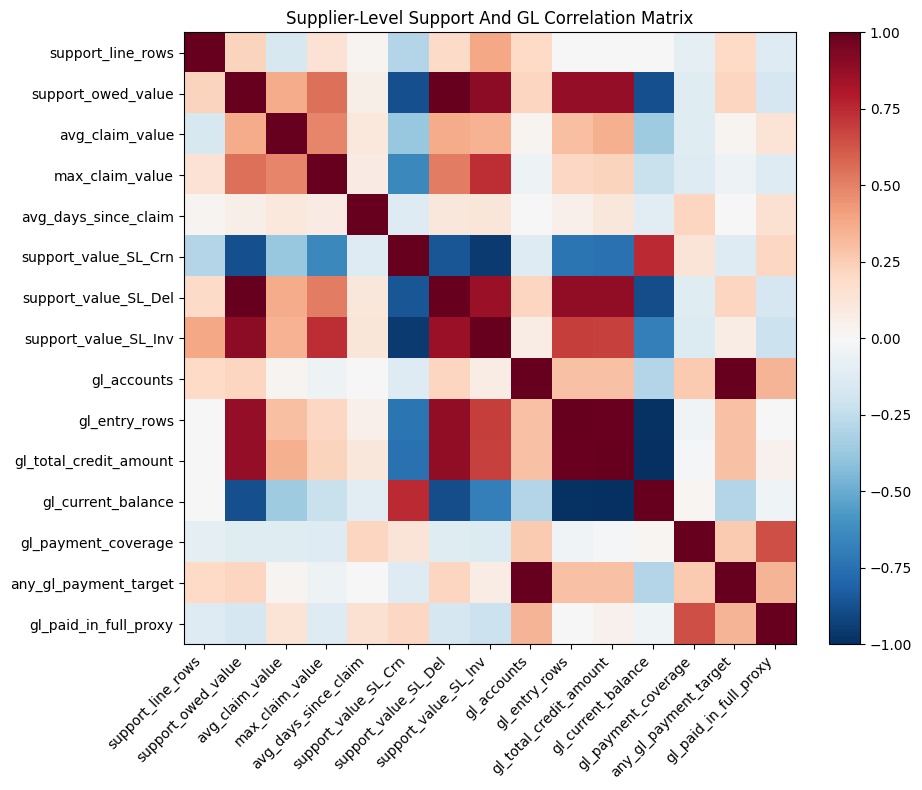

In [4]:
correlation_cols = [col for col in [
    "support_line_rows",
    "support_owed_value",
    "avg_claim_value",
    "max_claim_value",
    "avg_days_since_claim",
    "support_value_SL_Crn",
    "support_value_SL_Del",
    "support_value_SL_Inv",
    "gl_accounts",
    "gl_entry_rows",
    "gl_total_credit_amount",
    "gl_current_balance",
    "gl_payment_coverage",
    "any_gl_payment_target",
    "gl_paid_in_full_proxy",
] if col in gl_model_base.columns]

corr = gl_model_base[correlation_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Supplier-Level Support And GL Correlation Matrix")
plt.tight_layout()
plt.show()


## Leakage Check

The realistic model can use support-side features only


In [5]:
gl_leakage_cols = [
    "gl_accounts",
    "gl_entry_rows",
    "gl_total_credit_amount",
    "gl_current_balance",
    "gl_latest_running_balance",
    "gl_payment_coverage",
    "gl_paid_in_full_proxy",
    "gl_payment_status_proxy",
    "gl_account_codes",
    "gl_account_descriptions",
    "gl_first_entry_date",
    "gl_last_entry_date",
    target_col,
]

support_only_features = [
    col for col in gl_model_base.columns
    if col not in gl_leakage_cols
    and not str(col).startswith("gl_")
    and col not in ["first_claim_date", "last_claim_date"]
]

leaky_features = [
    col for col in gl_model_base.columns
    if col not in [target_col, "gl_payment_status_proxy", "gl_account_codes", "gl_account_descriptions"]
    and col not in ["first_claim_date", "last_claim_date", "gl_first_entry_date", "gl_last_entry_date"]
]

print("Support-only features used for realistic model:")
print(support_only_features)
print("Features that may cause leakage:")
print([col for col in leaky_features if str(col).startswith("gl_")])


Support-only features used for realistic model:
['supplier_group_code', 'supplier_name', 'support_line_rows', 'support_owed_value', 'avg_claim_value', 'max_claim_value', 'avg_days_since_claim', 'support_value_SL_Crn', 'support_value_SL_Del', 'support_value_SL_Inv']
Features that may cause leakage:
['gl_accounts', 'gl_entry_rows', 'gl_total_credit_amount', 'gl_current_balance', 'gl_payment_coverage', 'gl_paid_in_full_proxy']


Leave-one-out validation is used because there are only 21 supplier groups.


In [6]:
def make_preprocess(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
    )
    return preprocess, numeric_features, categorical_features

X_support = gl_model_base[support_only_features].copy()
X_support[X_support.select_dtypes(include=["object", "category", "string"]).columns] = X_support.select_dtypes(include=["object", "category", "string"]).astype(str).fillna("missing")
y = gl_model_base[target_col]

preprocess, numeric_features, categorical_features = make_preprocess(X_support)
classifier = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        class_weight="balanced",
    )),
])

loo = LeaveOneOut()
class_pred = cross_val_predict(classifier, X_support, y, cv=loo)
class_proba = cross_val_predict(classifier, X_support, y, cv=loo, method="predict_proba")[:, 1]
probability_rmse = np.sqrt(mean_squared_error(y, class_proba))

print("Probability RMSE:", round(probability_rmse, 3))
print("Accuracy:", round(accuracy_score(y, class_pred), 3))
print(confusion_matrix(y, class_pred))
print(classification_report(y, class_pred, target_names=["No GL payment evidence", "GL payment evidence"]))
if y.nunique() == 2:
    print("ROC AUC:", round(roc_auc_score(y, class_proba), 3))

classification_results = gl_model_base[["supplier_group_code", "supplier_name", target_col, "support_owed_value", "gl_total_credit_amount"]].copy()
classification_results["predicted_payment_evidence"] = class_pred
classification_results["predicted_payment_probability"] = class_proba
display(classification_results.sort_values("predicted_payment_probability", ascending=False))


Probability RMSE: 0.557
Accuracy: 0.538
[[ 2  8]
 [ 4 12]]
                        precision    recall  f1-score   support

No GL payment evidence       0.33      0.20      0.25        10
   GL payment evidence       0.60      0.75      0.67        16

              accuracy                           0.54        26
             macro avg       0.47      0.47      0.46        26
          weighted avg       0.50      0.54      0.51        26

ROC AUC: 0.381


,supplier_group_code,supplier_name,any_gl_payment_target,support_owed_value,gl_total_credit_amount,predicted_payment_evidence,predicted_payment_probability
23,U102,Supplier4,False,3.162448e+05,0.00,True,0.940000
6,E102,Supplier7,False,4.357197e+04,0.00,True,0.906667
19,L812,Supplier14,False,1.388804e+04,0.00,True,0.816667
13,E631,Supplier16,False,9.448745e+03,0.00,True,0.813333
4,E070,Supplier19,True,3.050484e+05,9124.28,True,0.810000
24,U106,Supplier1,True,2.632074e+05,3744.41,True,0.773333
11,E555,Supplier18,True,1.910249e+05,46476.48,True,0.733333
3,E059,Supplier5,False,1.171940e+04,0.00,True,0.723333
18,L810,Supplier14,True,1.135439e+04,9328.19,True,0.710000
5,E071,Supplier13,True,1.006174e+06,242784.06,True,0.710000


## Forest Regression w/ GL entries

RMSE is reported in currency terms, so a high RMSE means the predicted payment amount is not close enough to the actual GL credit amount.

In [7]:
regression_features = [col for col in support_only_features if col not in ["supplier_group_code", "supplier_name"]]
X_reg = gl_model_base[regression_features].copy()
X_reg[X_reg.select_dtypes(include=["object", "category", "string"]).columns] = X_reg.select_dtypes(include=["object", "category", "string"]).astype(str).fillna("missing")
y_reg = gl_model_base[value_target_col]

reg_preprocess, _, _ = make_preprocess(X_reg)
regressor = Pipeline(steps=[
    ("preprocess", reg_preprocess),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
    )),
])

reg_pred = cross_val_predict(regressor, X_reg, y_reg, cv=LeaveOneOut())
rmse = np.sqrt(mean_squared_error(y_reg, reg_pred))
mae = mean_absolute_error(y_reg, reg_pred)
r2 = r2_score(y_reg, reg_pred)

print("Leave-one-out support-only GL credit amount regressor")
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))
print("R2:", round(r2, 3))

regression_results = gl_model_base[["supplier_group_code", "supplier_name", "support_owed_value", value_target_col]].copy()
regression_results["predicted_gl_credit_amount"] = reg_pred
regression_results["absolute_error"] = (regression_results[value_target_col] - regression_results["predicted_gl_credit_amount"]).abs()
display(regression_results.sort_values("absolute_error", ascending=False))


Leave-one-out support-only GL credit amount regressor
RMSE: 48487.59
MAE: 21462.67
R2: -0.053


,supplier_group_code,supplier_name,support_owed_value,gl_total_credit_amount,predicted_gl_credit_amount,absolute_error
5,E071,Supplier13,1.006174e+06,242784.06,12373.417467,230410.642533
23,U102,Supplier4,3.162448e+05,0.00,44761.282533,44761.282533
15,E907GB,Supplier21GB,1.343000e+04,34587.00,2077.852467,32509.147533
11,E555,Supplier18,1.910249e+05,46476.48,14270.934000,32205.546000
12,E555GB,Supplier18GB,4.238224e+04,46476.48,15374.361133,31102.118867
24,U106,Supplier1,2.632074e+05,3744.41,31262.437567,27518.027567
3,E059,Supplier5,1.171940e+04,0.00,24870.882900,24870.882900
14,E907,Supplier21,1.826870e+05,34587.00,13577.965200,21009.034800
6,E102,Supplier7,4.357197e+04,0.00,14621.249300,14621.249300
1,E022,Supplier9,2.147108e+04,5774.89,20187.075067,14412.185067


This GL target is a better modelling example than the original IQ status target because it uses actual ledger payment evidence. However, the evidence is still limited as there are only 21 supplier groups, the GL target is account-level, and payment amount can be heavily concentrated in a few suppliers. This should then remain a reconciliation model, with the GL model presented as a promising investigation and prioritisation method.


In [8]:
for name in [
    "matched", "df_model_base", "quality_report", "missing_after_cleaning", "gl_account_summary",
    "gl_account_summary_clean", "supplier_follow_up_priority_list", "model_results",
    "classification_results", "regression_results", "valid_date_check", "summary",
    "year_view", "month_view", "supplier_summary", "monthly_summary"
]:
    if name in globals():
        obj = globals()[name]
        print(name, getattr(obj, "shape", ""))
        try:
            display(obj.head(10))
        except AttributeError:
            display(obj)


gl_account_summary (15, 9)


,gl_account_code,gl_account_description,gl_supplier_key,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date,gl_current_balance,gl_current_balance_abs
0,01-85001,Supplier13 E071 Claimbacks,SUPPLIER13,105,242784.06,2026-05-01,2026-07-03,-242784.06,242784.06
1,01-85002,Supplier2 E005 Claimbacks,SUPPLIER2,1,6240.00,2026-02-25,2026-02-25,-6240.00,6240.00
2,01-85007,Supplier9 E022 Claimbacks,SUPPLIER9,5,5774.89,2026-02-09,2026-07-10,-5774.89,5774.89
3,01-85017,Supplier3 E055 Claimbacks,SUPPLIER3,4,5550.00,2026-03-17,2026-07-14,-5550.00,5550.00
4,01-85021,Supplier19 E070 Claimbacks,SUPPLIER19,4,9124.28,2026-04-20,2026-04-20,-9124.28,9124.28
5,01-85036,Supplier8 E175 Claimbacks,SUPPLIER8,2,4782.68,2026-04-23,2026-06-04,-4782.68,4782.68
6,01-85046,Supplier10 E234 Claimbacks,SUPPLIER10,8,925.00,2026-04-08,2026-07-16,-925.00,925.00
7,01-85056,Supplier17 E269A Claimbacks,SUPPLIER17,1,576.00,2026-06-17,2026-06-17,-576.00,576.00
8,01-85079,Supplier18 E555 Claimbacks,SUPPLIER18,11,46476.48,2026-02-24,2026-07-22,-46476.48,46476.48
9,01-85115,Supplier20 E948 Claimbacks,SUPPLIER20,5,3431.79,2026-02-24,2026-06-26,-3431.79,3431.79


gl_account_summary_clean (15, 9)


,gl_account_code,gl_account_description,gl_supplier_key,gl_entry_rows,gl_total_credit_amount,gl_first_entry_date,gl_last_entry_date,gl_current_balance,gl_current_balance_abs
0,01-85001,Supplier13 E071 Claimbacks,SUPPLIER13,105,242784.06,2026-05-01,2026-07-03,-242784.06,242784.06
1,01-85002,Supplier2 E005 Claimbacks,SUPPLIER2,1,6240.00,2026-02-25,2026-02-25,-6240.00,6240.00
2,01-85007,Supplier9 E022 Claimbacks,SUPPLIER9,5,5774.89,2026-02-09,2026-07-10,-5774.89,5774.89
3,01-85017,Supplier3 E055 Claimbacks,SUPPLIER3,4,5550.00,2026-03-17,2026-07-14,-5550.00,5550.00
4,01-85021,Supplier19 E070 Claimbacks,SUPPLIER19,4,9124.28,2026-04-20,2026-04-20,-9124.28,9124.28
5,01-85036,Supplier8 E175 Claimbacks,SUPPLIER8,2,4782.68,2026-04-23,2026-06-04,-4782.68,4782.68
6,01-85046,Supplier10 E234 Claimbacks,SUPPLIER10,8,925.00,2026-04-08,2026-07-16,-925.00,925.00
7,01-85056,Supplier17 E269A Claimbacks,SUPPLIER17,1,576.00,2026-06-17,2026-06-17,-576.00,576.00
8,01-85079,Supplier18 E555 Claimbacks,SUPPLIER18,11,46476.48,2026-02-24,2026-07-22,-46476.48,46476.48
9,01-85115,Supplier20 E948 Claimbacks,SUPPLIER20,5,3431.79,2026-02-24,2026-06-26,-3431.79,3431.79


classification_results (26, 7)


,supplier_group_code,supplier_name,any_gl_payment_target,support_owed_value,gl_total_credit_amount,predicted_payment_evidence,predicted_payment_probability
0,E005GB,Supplier2GB,True,5.014200e+02,6240.00,False,0.280000
1,E022,Supplier9,True,2.147108e+04,5774.89,True,0.656667
2,E055,Supplier3,True,1.150500e+04,5550.00,True,0.523333
3,E059,Supplier5,False,1.171940e+04,0.00,True,0.723333
4,E070,Supplier19,True,3.050484e+05,9124.28,True,0.810000
5,E071,Supplier13,True,1.006174e+06,242784.06,True,0.710000
6,E102,Supplier7,False,4.357197e+04,0.00,True,0.906667
7,E175,Supplier8,True,1.501143e+04,4782.68,True,0.663333
8,E234,Supplier10,True,6.150000e+02,925.00,False,0.313333
9,E242,Supplier12,False,1.088950e+03,0.00,True,0.576667


regression_results (26, 6)


,supplier_group_code,supplier_name,support_owed_value,gl_total_credit_amount,predicted_gl_credit_amount,absolute_error
0,E005GB,Supplier2GB,5.014200e+02,6240.00,1460.079767,4779.920233
1,E022,Supplier9,2.147108e+04,5774.89,20187.075067,14412.185067
2,E055,Supplier3,1.150500e+04,5550.00,5066.723800,483.276200
3,E059,Supplier5,1.171940e+04,0.00,24870.882900,24870.882900
4,E070,Supplier19,3.050484e+05,9124.28,15829.772400,6705.492400
5,E071,Supplier13,1.006174e+06,242784.06,12373.417467,230410.642533
6,E102,Supplier7,4.357197e+04,0.00,14621.249300,14621.249300
7,E175,Supplier8,1.501143e+04,4782.68,7649.497633,2866.817633
8,E234,Supplier10,6.150000e+02,925.00,4409.637767,3484.637767
9,E242,Supplier12,1.088950e+03,0.00,2295.185600,2295.185600
